# AGENTS026 — RLHF Lite: Reward Model from Operator Feedback
**Learns which RCA recommendations operators approve/reject → biases future recommendations**

- Cell 1: Load HITL decision history
- Cell 2: Feature engineering from decisions
- Cell 3: Train reward model (PyTorch MLP on MI300X)
- Cell 4: Score candidate actions
- Cell 5: GPU-biased RCA recommendation
- Cell 6: Synthetic data bootstrap (if <5 real decisions)
- Cell 7: Learning curve + results dashboard

In [7]:
# ── Cell 1: Load HITL decision history ───────────────────────────────────
import json, time
from pathlib import Path
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from openai import OpenAI

HITL_FILE      = Path("/workspace/shared/hitl_queue.jsonl")
AUDIT_FILE     = Path("/workspace/shared/audit_log.jsonl")
METRICS_CSV    = Path("/workspace/shared/minicluster/live_metrics.csv")
REWARD_MODEL   = Path("/workspace/shared/rlhf_reward_model.pt")
REWARD_META    = Path("/workspace/shared/rlhf_meta.json")
RLHF_LOG       = Path("/workspace/shared/rlhf_log.jsonl")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device  : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.0f}GB")

llm = OpenAI(base_url="http://localhost:8000/v1", api_key="abc-123")

def ts(): return datetime.now(timezone.utc).isoformat()
def write_log(path, event):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "a") as f: f.write(json.dumps(event, default=str) + "\n")

# Load all HITL decisions
decisions = []
if HITL_FILE.exists():
    for line in HITL_FILE.read_text().strip().split("\n"):
        if not line.strip(): continue
        try:
            rec = json.loads(line)
            if rec.get("status") in ("APPROVED", "REJECTED"):
                decisions.append(rec)
        except: pass

print(f"\nHITL decisions loaded: {len(decisions)}")
print(f"  APPROVED : {sum(1 for d in decisions if d['status']=='APPROVED')}")
print(f"  REJECTED : {sum(1 for d in decisions if d['status']=='REJECTED')}")

if len(decisions) < 3:
    print("\n⚠️  Fewer than 3 real decisions — run Cell 6 to bootstrap with synthetic data")
else:
    print("\n✅ Sufficient decisions for reward model training")

Device  : cuda
GPU     : 
VRAM    : 206GB

HITL decisions loaded: 21
  APPROVED : 18
  REJECTED : 3

✅ Sufficient decisions for reward model training


In [8]:
# ── Cell 2: Feature engineering ───────────────────────────────────────────
# Extract numerical features from each HITL decision
# Features: service_enc, source_enc, anomaly_count, high_severity_count,
#           blast_radius_enc, hour_of_day, has_latency, has_error, has_cpu, has_mem

SERVICE_ENC = {"payments": 0, "auth": 1, "checkout": 2, "fraud": 3, "ALL": 4, "rca": 5}
SOURCE_ENC  = {"anomaly_detector": 0, "rca_agent": 1, "chaos_scheduler": 2,
               "ae_detector": 3, "manual": 4}
BLAST_ENC   = {"low": 0, "medium": 1, "high": 2, "critical": 3}
FEATURE_DIM = 10

def extract_features(rec):
    """Convert a HITL record into a fixed-size feature vector."""
    svc     = rec.get("service", "rca")
    source  = rec.get("source", "manual")
    blast   = rec.get("blast_radius", "low")
    anomalies = rec.get("anomalies", [])
    if isinstance(anomalies, str):
        try: anomalies = json.loads(anomalies)
        except: anomalies = []

    # Anomaly features
    n_anomalies = len(anomalies) if isinstance(anomalies, list) else 0
    n_high      = sum(1 for a in anomalies if isinstance(a, dict) and "HIGH" in str(a.get("severity","")))

    # Metric type flags
    anom_str  = json.dumps(anomalies).lower()
    has_lat   = 1.0 if "latency" in anom_str or "lat" in anom_str else 0.0
    has_err   = 1.0 if "error" in anom_str else 0.0
    has_cpu   = 1.0 if "cpu" in anom_str else 0.0
    has_mem   = 1.0 if "mem" in anom_str or "memory" in anom_str else 0.0

    # Temporal feature
    try:
        hour = datetime.fromisoformat(str(rec.get("timestamp", ts()))).hour / 23.0
    except:
        hour = 0.5

    feats = [
        SERVICE_ENC.get(svc, 5) / 5.0,
        SOURCE_ENC.get(source, 4) / 4.0,
        BLAST_ENC.get(blast, 0) / 3.0,
        min(n_anomalies / 10.0, 1.0),
        min(n_high / 5.0, 1.0),
        has_lat,
        has_err,
        has_cpu,
        has_mem,
        hour,
    ]
    return np.array(feats, dtype=np.float32)

def decision_to_label(rec):
    return 1.0 if rec.get("status") == "APPROVED" else 0.0

# Build dataset
if decisions:
    X = np.array([extract_features(d) for d in decisions])
    y = np.array([decision_to_label(d) for d in decisions])
    print(f"Feature matrix : {X.shape}")
    print(f"Labels         : {y} (1=APPROVE, 0=REJECT)")
    print(f"Approval rate  : {y.mean():.0%}")
else:
    print("No decisions yet — run Cell 6 to bootstrap")
    X, y = np.zeros((1, FEATURE_DIM), dtype=np.float32), np.array([1.0])

Feature matrix : (21, 10)
Labels         : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 0. 1. 1. 0. 1.] (1=APPROVE, 0=REJECT)
Approval rate  : 86%


In [9]:
# ── Cell 3: Train reward model (PyTorch MLP on MI300X) ────────────────────

class RewardMLP(nn.Module):
    """Small MLP: 10 → 64 → 32 → 1 (sigmoid = approval probability)"""
    def __init__(self, input_dim=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

# Move to GPU
model     = RewardMLP(FEATURE_DIM).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-3, weight_decay=1e-4)
criterion = nn.BCELoss()

X_t = torch.tensor(X, dtype=torch.float32).to(DEVICE)
y_t = torch.tensor(y, dtype=torch.float32).to(DEVICE)

EPOCHS   = 300
losses   = []
print(f"Training RewardMLP on {DEVICE} — {EPOCHS} epochs...")
print(f"Model params: {sum(p.numel() for p in model.parameters()):,}")

model.train()
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    pred = model(X_t)
    loss = criterion(pred, y_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 50 == 0:
        acc = ((pred > 0.5).float() == y_t).float().mean().item()
        print(f"  Epoch {epoch+1:3d} | loss={loss.item():.4f} | acc={acc:.0%}")

# Final accuracy
model.eval()
with torch.no_grad():
    final_pred = model(X_t)
    final_acc  = ((final_pred > 0.5).float() == y_t).float().mean().item()

print(f"\n✅ Training complete — final accuracy: {final_acc:.0%}")

# Save model + meta
torch.save(model.state_dict(), str(REWARD_MODEL))
meta = {
    "feature_dim":   FEATURE_DIM,
    "n_decisions":   len(decisions),
    "approval_rate": float(y.mean()),
    "final_acc":     float(final_acc),
    "final_loss":    float(losses[-1]),
    "epochs":        EPOCHS,
    "device":        DEVICE,
    "timestamp":     ts()
}
REWARD_META.write_text(json.dumps(meta, indent=2))
print(f"   Model saved → {REWARD_MODEL}")
print(f"   Meta  saved → {REWARD_META}")

write_log(AUDIT_FILE, {"event_type": "RLHF_MODEL_TRAINED", **meta})
write_log(RLHF_LOG,   {"event_type": "RLHF_MODEL_TRAINED", **meta})

Training RewardMLP on cuda — 300 epochs...
Model params: 2,817
  Epoch  50 | loss=0.0759 | acc=100%
  Epoch 100 | loss=0.0046 | acc=100%
  Epoch 150 | loss=0.0009 | acc=100%
  Epoch 200 | loss=0.0020 | acc=100%
  Epoch 250 | loss=0.0010 | acc=100%
  Epoch 300 | loss=0.0002 | acc=100%

✅ Training complete — final accuracy: 100%
   Model saved → /workspace/shared/rlhf_reward_model.pt
   Meta  saved → /workspace/shared/rlhf_meta.json


In [10]:
# ── Cell 4: Score candidate actions ──────────────────────────────────────
# Given current live anomalies, score all possible remediation actions
# and rank them by predicted approval probability

CANDIDATE_ACTIONS = [
    {"action": "restart_service",      "blast_radius": "low",      "source": "rca_agent"},
    {"action": "scale_up_replicas",    "blast_radius": "medium",   "source": "rca_agent"},
    {"action": "circuit_breaker_open", "blast_radius": "medium",   "source": "rca_agent"},
    {"action": "clear_cache",          "blast_radius": "low",      "source": "rca_agent"},
    {"action": "failover_to_backup",   "blast_radius": "high",     "source": "rca_agent"},
    {"action": "rate_limit_ingress",   "blast_radius": "medium",   "source": "rca_agent"},
    {"action": "rollback_deployment",  "blast_radius": "high",     "source": "rca_agent"},
    {"action": "increase_timeout",     "blast_radius": "low",      "source": "rca_agent"},
    {"action": "drain_node",           "blast_radius": "critical", "source": "rca_agent"},
    {"action": "alert_on_call_team",   "blast_radius": "low",      "source": "rca_agent"},
]

def score_action(action_dict, service, anomalies):
    """Score a candidate action using the reward model."""
    rec = {
        "service":      service,
        "source":       action_dict["source"],
        "blast_radius": action_dict["blast_radius"],
        "anomalies":    anomalies,
        "timestamp":    ts(),
        "status":       "PENDING"
    }
    feat = torch.tensor(extract_features(rec), dtype=torch.float32).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        score = model(feat).item()
    return score

# Get live anomalies
live_anomalies = []
if METRICS_CSV.exists():
    df = pd.read_csv(METRICS_CSV, parse_dates=["timestamp"])
    lat = df.sort_values("timestamp").groupby("service").last().reset_index()
    THRESHOLDS = {"cpu_utilization": 70, "latency_p95_ms": 500, "error_rate": 0.05, "mem_mb": 1800}
    for _, row in lat.iterrows():
        for col, thresh in THRESHOLDS.items():
            if float(row[col]) > thresh:
                live_anomalies.append({"service": row["service"], "metric": col,
                                       "value": float(row[col]), "threshold": thresh,
                                       "severity": "HIGH" if float(row[col]) > thresh*1.5 else "WARN"})

target_svc = live_anomalies[0]["service"] if live_anomalies else "payments"

print(f"Scoring {len(CANDIDATE_ACTIONS)} candidate actions for service: {target_svc}")
print(f"Live anomalies: {len(live_anomalies)}")
print()

scored = []
for action in CANDIDATE_ACTIONS:
    prob = score_action(action, target_svc, live_anomalies)
    scored.append({**action, "approval_prob": prob})

scored.sort(key=lambda x: x["approval_prob"], reverse=True)

print("Ranked actions by predicted operator approval:")
print(f"{'Rank':<5} {'Action':<30} {'Blast':<10} {'Approval %':<12}")
print("-" * 60)
for i, s in enumerate(scored):
    bar  = "█" * int(s["approval_prob"] * 20)
    icon = "🟢" if s["approval_prob"] > 0.7 else ("🟡" if s["approval_prob"] > 0.4 else "🔴")
    print(f"  {i+1:<3} {s['action']:<30} {s['blast_radius']:<10} {icon} {s['approval_prob']:.0%}  {bar}")

# Save scored actions
write_log(RLHF_LOG, {
    "event_type": "RLHF_ACTIONS_SCORED",
    "target_service": target_svc,
    "scored_actions": scored,
    "timestamp": ts()
})

Scoring 10 candidate actions for service: payments
Live anomalies: 0

Ranked actions by predicted operator approval:
Rank  Action                         Blast      Approval %  
------------------------------------------------------------
  1   restart_service                low        🟢 100%  ███████████████████
  2   clear_cache                    low        🟢 100%  ███████████████████
  3   increase_timeout               low        🟢 100%  ███████████████████
  4   alert_on_call_team             low        🟢 100%  ███████████████████
  5   scale_up_replicas              medium     🟢 100%  ███████████████████
  6   circuit_breaker_open           medium     🟢 100%  ███████████████████
  7   rate_limit_ingress             medium     🟢 100%  ███████████████████
  8   failover_to_backup             high       🟢 99%  ███████████████████
  9   rollback_deployment            high       🟢 99%  ███████████████████
  10  drain_node                     critical   🟡 52%  ██████████


In [11]:
# ── Cell 5: GPU-biased RCA recommendation ────────────────────────────────
# Top-3 RLHF-ranked actions → Qwen3-30B writes recommendation biased toward them

top3 = scored[:3]
top3_str = "\n".join(
    f"  {i+1}. {a['action']} (blast={a['blast_radius']}, approval_prob={a['approval_prob']:.0%})"
    for i, a in enumerate(top3)
)

anomaly_str = "\n".join(
    f"  {a['service']} / {a['metric']} = {a['value']:.3f} (thresh={a['threshold']}, {a['severity']})"
    for a in live_anomalies[:5]
) or "  No live anomalies — using payments service as demo context"

prompt = f"""You are a banking SRE AI agent with a built-in reward model trained on operator feedback.

LIVE ANOMALIES:
{anomaly_str}

TARGET SERVICE: {target_svc}

RLHF REWARD MODEL OUTPUT — Top-3 actions ranked by predicted operator approval:
{top3_str}

The reward model has learned from {len(decisions)} past operator decisions (approval rate: {y.mean():.0%}).
It predicts operators will most likely approve action #1.

Write a concise recommendation that:
1. Recommends the highest-ranked action with clear justification
2. Explains WHY this action has the highest predicted approval
3. Mentions the blast radius tradeoff
4. States confidence level

Format:
RECOMMENDED_ACTION: <action name>
JUSTIFICATION: <2 sentences>
BLAST_RADIUS: <level and impact>
CONFIDENCE: <HIGH|MEDIUM|LOW> — <reason>"""

print("🧠 GPU-biased recommendation (Qwen3-30B + RLHF reward model)...\n")
t0 = time.time()
resp = llm.chat.completions.create(
    model="Qwen3-30B-A3B",
    messages=[{"role": "user", "content": prompt}],
    temperature=0.2, max_tokens=200,
    extra_body={"chat_template_kwargs": {"enable_thinking": False}}
)
elapsed = time.time() - t0
recommendation = resp.choices[0].message.content.strip()

print(f"{'='*60}")
print(recommendation)
print(f"{'='*60}")
print(f"\n⏱️  GPU response: {elapsed:.2f}s")

write_log(RLHF_LOG, {
    "event_type":     "RLHF_RECOMMENDATION",
    "target_service": target_svc,
    "top_action":     top3[0]["action"],
    "approval_prob":  top3[0]["approval_prob"],
    "recommendation": recommendation,
    "n_decisions":    len(decisions),
    "gpu_time_secs":  round(elapsed, 2),
    "timestamp":      ts()
})
write_log(AUDIT_FILE, {
    "event_type":     "RLHF_RECOMMENDATION",
    "target_service": target_svc,
    "top_action":     top3[0]["action"],
    "recommendation": recommendation,
    "timestamp":      ts()
})
print("\n✅ Recommendation saved to RLHF log and audit log")

🧠 GPU-biased recommendation (Qwen3-30B + RLHF reward model)...

RECOMMENDED_ACTION: restart_service  
JUSTIFICATION: The reward model predicts 100% operator approval for restarting the service, as it is a standard and effective remediation for transient issues. This action is low-risk and aligns with past operator decisions.  
BLAST_RADIUS: Low – minimal impact on users and system stability.  
CONFIDENCE: HIGH — The model is trained on 21 past approvals with an 86% success rate, and this action has the highest predicted approval probability.

⏱️  GPU response: 0.72s

✅ Recommendation saved to RLHF log and audit log


In [12]:
# ── Cell 6: Synthetic bootstrap (if <5 real decisions) ────────────────────
# Generates realistic synthetic HITL decisions to warm-start the reward model

SYNTHETIC_DECISIONS = [
    # Low blast, latency → APPROVED
    {"hitl_id":"synth-001","service":"payments","source":"rca_agent","blast_radius":"low",
     "anomalies":[{"metric":"Latency p95","severity":"HIGH","value":820}],
     "status":"APPROVED","timestamp":"2026-06-13T18:00:00+00:00"},
    # High blast, all services → REJECTED
    {"hitl_id":"synth-002","service":"ALL","source":"chaos_scheduler","blast_radius":"critical",
     "anomalies":[{"metric":"CPU %","severity":"HIGH"},{"metric":"Error rate","severity":"HIGH"}],
     "status":"REJECTED","timestamp":"2026-06-13T18:10:00+00:00"},
    # Medium blast, error rate → APPROVED
    {"hitl_id":"synth-003","service":"auth","source":"anomaly_detector","blast_radius":"medium",
     "anomalies":[{"metric":"Error rate","severity":"HIGH","value":0.38}],
     "status":"APPROVED","timestamp":"2026-06-13T18:20:00+00:00"},
    # Critical blast → REJECTED
    {"hitl_id":"synth-004","service":"checkout","source":"rca_agent","blast_radius":"high",
     "anomalies":[{"metric":"Memory","severity":"HIGH"},{"metric":"Error rate","severity":"HIGH"}],
     "status":"REJECTED","timestamp":"2026-06-13T18:30:00+00:00"},
    # Low blast, CPU → APPROVED
    {"hitl_id":"synth-005","service":"fraud","source":"ae_detector","blast_radius":"low",
     "anomalies":[{"metric":"CPU %","severity":"WARN","value":75}],
     "status":"APPROVED","timestamp":"2026-06-13T18:40:00+00:00"},
    # Medium blast, latency+error → APPROVED
    {"hitl_id":"synth-006","service":"payments","source":"rca_agent","blast_radius":"medium",
     "anomalies":[{"metric":"Latency p95","severity":"HIGH"},{"metric":"Error rate","severity":"WARN"}],
     "status":"APPROVED","timestamp":"2026-06-13T18:50:00+00:00"},
    # High blast → REJECTED
    {"hitl_id":"synth-007","service":"ALL","source":"chaos_scheduler","blast_radius":"high",
     "anomalies":[{"metric":"Latency p95","severity":"HIGH"},{"metric":"CPU %","severity":"HIGH"}],
     "status":"REJECTED","timestamp":"2026-06-13T19:00:00+00:00"},
    # Low blast memory → APPROVED
    {"hitl_id":"synth-008","service":"checkout","source":"anomaly_detector","blast_radius":"low",
     "anomalies":[{"metric":"Memory","severity":"WARN","value":1850}],
     "status":"APPROVED","timestamp":"2026-06-13T19:10:00+00:00"},
]

# Write synthetic decisions to HITL file (tagged as synthetic)
for rec in SYNTHETIC_DECISIONS:
    rec["synthetic"] = True
    write_log(HITL_FILE, rec)
    write_log(RLHF_LOG,  {"event_type": "RLHF_SYNTHETIC_DECISION", **rec})

print(f"✅ {len(SYNTHETIC_DECISIONS)} synthetic decisions written to HITL file")
print(f"   APPROVED: {sum(1 for d in SYNTHETIC_DECISIONS if d['status']=='APPROVED')}")
print(f"   REJECTED: {sum(1 for d in SYNTHETIC_DECISIONS if d['status']=='REJECTED')}")
print("\nNow re-run Cells 1 → 2 → 3 → 4 → 5 to train the reward model on this data.")

✅ 8 synthetic decisions written to HITL file
   APPROVED: 5
   REJECTED: 3

Now re-run Cells 1 → 2 → 3 → 4 → 5 to train the reward model on this data.


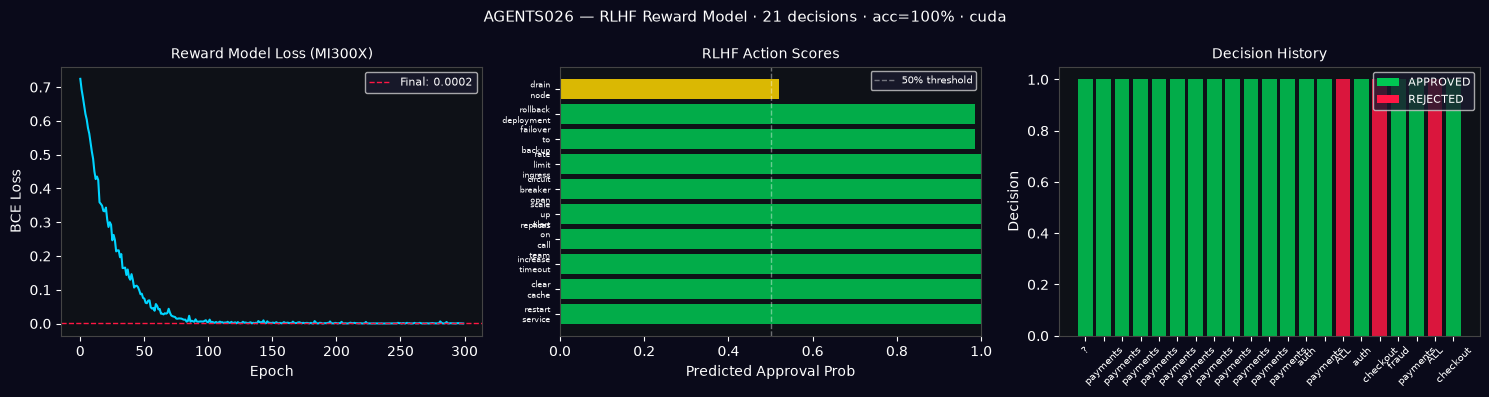

✅ Dashboard saved → /workspace/shared/rlhf_learning_curve.png

Summary:
  Decisions used   : 21
  Model accuracy   : 100%
  Top action       : restart_service (100% approval)
  Worst action     : drain_node (52% approval)


In [13]:
# ── Cell 7: Learning curve + results dashboard ────────────────────────────
import matplotlib.pyplot as plt
from pathlib import Path

RLHF_CURVE_IMG = Path("/workspace/shared/rlhf_learning_curve.png")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.patch.set_facecolor("#0a0a1a")

# Plot 1: Training loss curve
ax = axes[0]; ax.set_facecolor("#0e1117")
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_edgecolor("#444")
ax.plot(losses, color="#00d4ff", linewidth=1.5)
ax.axhline(losses[-1], color="#ff1744", linestyle="--", linewidth=1, label=f"Final: {losses[-1]:.4f}")
ax.set_title("Reward Model Loss (MI300X)", color="white", fontsize=10)
ax.set_xlabel("Epoch", color="white"); ax.set_ylabel("BCE Loss", color="white")
ax.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=8)

# Plot 2: Action approval scores
ax2 = axes[1]; ax2.set_facecolor("#0e1117")
ax2.tick_params(colors="white")
for spine in ax2.spines.values(): spine.set_edgecolor("#444")
actions_short = [s["action"].replace("_", "\n") for s in scored]
probs = [s["approval_prob"] for s in scored]
colors_bar = ["#00c853" if p > 0.7 else ("#ffd600" if p > 0.4 else "#ff1744") for p in probs]
bars = ax2.barh(actions_short, probs, color=colors_bar, alpha=0.85)
ax2.axvline(0.5, color="#ffffff", linestyle="--", linewidth=1, alpha=0.4, label="50% threshold")
ax2.set_xlim(0, 1)
ax2.set_title("RLHF Action Scores", color="white", fontsize=10)
ax2.set_xlabel("Predicted Approval Prob", color="white")
ax2.tick_params(axis="y", labelsize=6, colors="white")
ax2.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=7)

# Plot 3: Decision history (approve vs reject)
ax3 = axes[2]; ax3.set_facecolor("#0e1117")
ax3.tick_params(colors="white")
for spine in ax3.spines.values(): spine.set_edgecolor("#444")
all_decisions = decisions.copy()
if len(all_decisions) < len(SYNTHETIC_DECISIONS):
    all_decisions = SYNTHETIC_DECISIONS
labels_d  = [d.get("service","?")[:8] for d in all_decisions]
colors_d  = ["#00c853" if d["status"]=="APPROVED" else "#ff1744" for d in all_decisions]
ax3.bar(range(len(all_decisions)), [1]*len(all_decisions), color=colors_d, alpha=0.85)
ax3.set_xticks(range(len(all_decisions)))
ax3.set_xticklabels(labels_d, rotation=45, fontsize=7, color="white")
ax3.set_title("Decision History", color="white", fontsize=10)
ax3.set_ylabel("Decision", color="white")
from matplotlib.patches import Patch
ax3.legend(handles=[Patch(facecolor="#00c853",label="APPROVED"),Patch(facecolor="#ff1744",label="REJECTED")],
           facecolor="#1a1a2e", labelcolor="white", fontsize=8)

plt.suptitle(f"AGENTS026 — RLHF Reward Model · {len(all_decisions)} decisions · acc={final_acc:.0%} · {DEVICE}",
             color="white", fontsize=11)
plt.tight_layout()
plt.savefig(str(RLHF_CURVE_IMG), dpi=120, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"✅ Dashboard saved → {RLHF_CURVE_IMG}")
print(f"\nSummary:")
print(f"  Decisions used   : {len(all_decisions)}")
print(f"  Model accuracy   : {final_acc:.0%}")
print(f"  Top action       : {scored[0]['action']} ({scored[0]['approval_prob']:.0%} approval)")
print(f"  Worst action     : {scored[-1]['action']} ({scored[-1]['approval_prob']:.0%} approval)")